# Fine-tuning del modelo RoBERTuito para detección de maltrato

En el presente notebook se desarrolló paso a paso el entrenamiento de un modelo de clasificación de texto. Para esta tarea se utilizó RoBERTuíto, el cual es un modelo de lenguaje preentrenado para contenido generado por usuarios en español, entrenado siguiendo las directrices de RoBERTa.

El objetivo es realizar el fine-tuning del modelo para que sea capaz de determinar si un texto es clasificado como maltrato en español, mediante una clasificación binaria (negativo, positivo). Después del entrenamiento se almacenará el mejor modelo, el cual será incorporado en un API dentro del prototipo final.

In [6]:
#pip install sympy==1.12 --force-reinstall

In [7]:
!pip install evaluate

tutorial oficial https://huggingface.co/docs/transformers/tasks/sequence_classification

Instalación de las librerias necesarias.

In [8]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, AutoTokenizer, pipeline, DataCollatorWithPadding
from huggingface_hub import notebook_login
from datasets import load_dataset, Value, concatenate_datasets
import evaluate
import numpy as np
from collections import Counter
import pandas as pd


Para poder cargar los datasets se debe autenticar con el sitio de HuggingFace mediante un token de acceso generado dentro del perfil del usuario. Esto se debe a que algunos de los datasets alojados en este sitio tienen restricciones de uso por lo cual no pueden ser cargados sin autenticación.

In [9]:
notebook_login()

https://huggingface.co/datasets/valeriobasile/HatEval

### Seleccion de datasets

### Dataset 1 dt1

Este conjunto de datos es un superconjunto (N=29.855) de publicaciones anotadas como de odio o no. Resulta del preprocesamiento y la fusión de todos los conjuntos de datos disponibles sobre discurso de odio en español en abril de 2024. Estos conjuntos de datos se identificaron mediante un estudio sistemático de conjuntos de datos sobre discurso de odio realizado a principios de 2024.
https://huggingface.co/datasets/manueltonneau/spanish-hate-speech-superset

In [10]:
dt1 = load_dataset("manueltonneau/spanish-hate-speech-superset")

es_hf_102024.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29855 [00:00<?, ? examples/s]

In [11]:
dt1

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'source', 'dataset', 'nb_annotators', 'tweet_id', 'post_author_country_location'],
        num_rows: 29855
    })
})

### Dataset 2 dt2

Se centra en jóvenes influencers de las conocidas plataformas sociales Twitter, Instagram y YouTube, han recopilado un corpus compuesto por comentarios en español etiquetados manualmente en categorías predefinidas de contenido ofensivo. Del corpus total, seleccionaron 30.416 publicaciones para su publicación, las cuales corresponden a las utilizadas en el concurso MeOffendES de IberLEF 2021.

https://huggingface.co/datasets/SINAI/OffendES

In [12]:
dt2 = load_dataset("SINAI/OffendES")

README.md: 0.00B [00:00, ?B/s]

training_set.tsv: 0.00B [00:00, ?B/s]

dev_set.tsv: 0.00B [00:00, ?B/s]

test_set.tsv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/16710 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/13606 [00:00<?, ? examples/s]

In [13]:
dt2

DatasetDict({
    train: Dataset({
        features: ['comment_id', 'comment', 'influencer', 'influencer_gender', 'media', 'label'],
        num_rows: 16710
    })
    validation: Dataset({
        features: ['comment_id', 'comment', 'influencer', 'influencer_gender', 'media', 'label'],
        num_rows: 100
    })
    test: Dataset({
        features: ['comment_id', 'comment', 'influencer', 'influencer_gender', 'media', 'label'],
        num_rows: 13606
    })
})

Datos por modelo

In [14]:
print( "Dataset 1 manueltonneau/spanish-hate-speech-superset train: " + str(len(dt1["train"])))
print( "Dataset 3 SINAI/OffendES train: " + str(len(dt2["train"])) + " validation: " + str(len(dt2["validation"])) + " test: " + str(len(dt2["test"])))

Dataset 1 manueltonneau/spanish-hate-speech-superset train: 29855
Dataset 3 SINAI/OffendES train: 16710 validation: 100 test: 13606


### Preparación de los datos

Para el entrenamiento del modelo se siguio el siguiente tutorial de HugginFace https://huggingface.co/docs/transformers/tasks/sequence_classification  

El modelo espara un dataset de entrenamiento y validación con una columna de text y una columna label con un valor que corresponde a 0 una clasificación negativa o 1 a una clasificación positiva. Por lo cual se necesita preparar todos los datasets utilizados.


## Dataset 1

Visualización de dataset 1

In [15]:
dt1["train"].to_pandas()

,text,labels,source,dataset,nb_annotators,tweet_id,post_author_country_location
0,Eran tan pero tan feministas que invisibilizab...,0.0,Twitter,chileno,3,1.401281e+18,unknown
1,@USER @USER @USER Me carga en lo q se convirti...,0.0,Twitter,chileno,3,1.402708e+18,Chile
2,", ¿Sabrán las femiorcas como @USER y todo el f...",1.0,Twitter,chileno,3,1.402623e+18,unknown
3,@USER @USER @USER @USER Una vecina que nada te...,0.0,Twitter,chileno,3,1.402472e+18,Chile
4,@USER Debajo de que piedra estaba ese flaiterio?,0.0,Twitter,chileno,3,1.401715e+18,unknown
...,...,...,...,...,...,...,...
29850,Un debate interesante ¿las mujeres occidentale...,0.0,Twitter,hascosva,3,NaN,unknown
29851,@USER @USER De todo esto y leyendo las respues...,0.0,Twitter,hascosva,3,NaN,unknown
29852,@USER @USER la reina respeta la religión musul...,0.0,Twitter,hascosva,3,NaN,unknown
29853,"""Las decisiones económicas son exclusivas del ...",0.0,Twitter,hascosva,3,NaN,unknown


Eliminación de columnas innecesarias.

In [16]:
dt1 =dt1["train"].remove_columns(["source", "dataset", "nb_annotators", "tweet_id", "post_author_country_location"])

Eliminacion de @USER

In [17]:
dt1 = dt1.map(
    lambda x: {"text": x["text"].replace("@USER", "usuario")}
)

Map:   0%|          | 0/29855 [00:00<?, ? examples/s]

Eliminacion de las urls

In [18]:
dt1 = dt1.map(
    lambda x: {"text": x["text"].replace("URL", "enlace")}
)

Map:   0%|          | 0/29855 [00:00<?, ? examples/s]

Cambio de tipo en columna labels ya que el modelo espera enteros y la columna original es flotante

In [19]:
dt1 = dt1.cast_column("labels", Value("int64"))

Casting the dataset:   0%|          | 0/29855 [00:00<?, ? examples/s]

In [20]:
Counter(dt1["labels"])

Counter({0: 22590, 1: 7265})

In [21]:
dt1.to_pandas()

,text,labels
0,Eran tan pero tan feministas que invisibilizab...,0
1,usuario usuario usuario Me carga en lo q se co...,0
2,", ¿Sabrán las femiorcas como usuario y todo el...",1
3,usuario usuario usuario usuario Una vecina que...,0
4,usuario Debajo de que piedra estaba ese flaite...,0
...,...,...
29850,Un debate interesante ¿las mujeres occidentale...,0
29851,usuario usuario De todo esto y leyendo las res...,0
29852,usuario usuario la reina respeta la religión m...,0
29853,"""Las decisiones económicas son exclusivas del ...",0


## Dataset 2

Visualización del dataset 2

In [22]:
dt2["train"].to_pandas()

,comment_id,comment,influencer,influencer_gender,media,label
0,52564,"En vez de la magia de mi melena, la magia de m...",dalas,man,instagram,NO
1,32984,"A ver, los milenials y la gente normal necesit...",soyunapringada,woman,youtube,NO
2,58447,Me encanta todo el contenido que haces se nota...,wildhater,man,instagram,NO
3,10341,a Laura sige así que vales mucho más que 10 o ...,lauraescane,woman,youtube,NO
4,53087,"Y si no mes gusta Dalas, que hacen aquí,lárgue...",dalas,man,instagram,NO
...,...,...,...,...,...,...
16705,57470,Hijo de tu puta madre estoy mamadisimo 😎,dalas,man,instagram,OFP
16706,35,"yo que hace 4 años lo veía, ahora me doy cuent...",dalas,man,twitter,OFP
16707,18564,Esta re blanco el wismi,wismichu,man,youtube,OFP
16708,46485,algo que no veo en esa botella rosada es que s...,windygirk,woman,youtube,OFP


Eliminar columnas

In [23]:
dt2_train =dt2["train"].remove_columns(["comment_id", "influencer", "influencer_gender", "media"])
dt2_val =dt2["validation"].remove_columns(["comment_id", "influencer", "influencer_gender", "media"])
dt2_test =dt2["test"].remove_columns(["comment_id", "influencer", "influencer_gender", "media"])

Mapear columnas

In [24]:
dt2_train = dt2_train.map(lambda x: {**x, "labels": 0 if x["label"] == "NO" else 1})
dt2_val = dt2_val.map(lambda x: {**x, "labels": 0 if x["label"] == "NO" else 1})
dt2_test = dt2_test.map(lambda x: {**x, "labels": 0 if x["label"] == "NO" else 1})

Map:   0%|          | 0/16710 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/13606 [00:00<?, ? examples/s]

In [25]:
dt2_train =dt2_train.remove_columns([ "label"])
dt2_val =dt2_val.remove_columns(["label"])
dt2_test =dt2_test.remove_columns([ "label"])

Renombrar columnas

In [26]:
dt2_train = dt2_train.rename_column("comment", "text")
dt2_val = dt2_val.rename_column("comment", "text")
dt2_test = dt2_test.rename_column("comment", "text")

In [27]:
Counter(dt2_train["labels"])
Counter(dt2_val["labels"])
Counter(dt2_test["labels"])

Counter({0: 9651, 1: 3955})

In [28]:
dt2_train.to_pandas()

,text,labels
0,"En vez de la magia de mi melena, la magia de m...",0
1,"A ver, los milenials y la gente normal necesit...",0
2,Me encanta todo el contenido que haces se nota...,0
3,a Laura sige así que vales mucho más que 10 o ...,0
4,"Y si no mes gusta Dalas, que hacen aquí,lárgue...",0
...,...,...
16705,Hijo de tu puta madre estoy mamadisimo 😎,1
16706,"yo que hace 4 años lo veía, ahora me doy cuent...",1
16707,Esta re blanco el wismi,1
16708,algo que no veo en esa botella rosada es que s...,1


Dividir dt1

In [29]:
split = dt1.train_test_split(test_size=0.1, seed=42)
split_train_val = split["train"].train_test_split(test_size=0.1, seed=42)

In [30]:
dt_train = concatenate_datasets([split_train_val["train"], dt2_train])
dt_test = concatenate_datasets([split["test"], dt2_test])
dt_val = concatenate_datasets([split_train_val["test"], dt2_val])

In [31]:
print("Datos de entrenamiento: ", Counter(dt_train["labels"]))
print("Datos de validación: ", Counter(dt_val["labels"]))
print("Datos de pruebas: ", Counter(dt_test["labels"]))

Datos de entrenamiento:  Counter({0: 31523, 1: 9369})
Datos de validación:  Counter({0: 2117, 1: 670})
Datos de pruebas:  Counter({0: 11877, 1: 4715})


In [32]:
import matplotlib.pyplot as plt

def plot_distribution(dataset, title, ax):
    counts = Counter(dataset["labels"])
    ax.bar(counts.keys(), counts.values())
    ax.set_title(title)
    ax.set_xlabel("Clase")
    ax.set_ylabel("Cantidad")


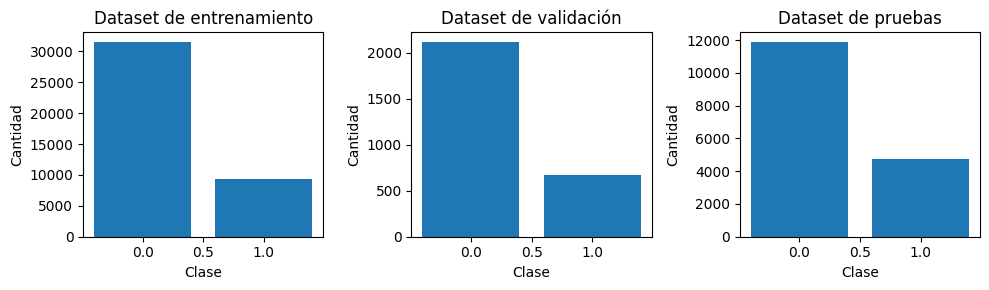

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

plot_distribution(dt_train, "Dataset de entrenamiento", axes[0])
plot_distribution(dt_val, "Dataset de validación", axes[1])
plot_distribution(dt_test, "Dataset de pruebas", axes[2])

plt.tight_layout()
plt.show()

## Entrenamiento del modelo

Modelo entrenado con el corpus TASS 2020 (unos 5000 tuits) de varios dialectos del español. El modelo base es RoBERTuito , un modelo RoBERTa entrenado con tuits en español.
https://huggingface.co/pysentimiento/robertuito-sentiment-analysis
modelo pysentimiento/robertuito-sentiment-analysis

El siguiente paso es cargar un tokenizador robertuito para preprocesar el campo text

In [34]:
tokenizer = AutoTokenizer.from_pretrained("pysentimiento/robertuito-sentiment-analysis")

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Se crea una función de preprocesamiento para tokenizar text y truncar secuencias de modo que no superen la longitud máxima de entrada del modelo

In [35]:
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True)

Utiliza la función de mapeo para aplicar la funció de preprocesamiento a todo el dataset. El valor batched=True permite el procesamiento de varios elementos del conjunto de datos a la vez.

In [36]:
tokenized_train = dt_train.map(preprocess_function, batched=True)
tokenized_val = dt_val.map(preprocess_function, batched=True)

Map:   0%|          | 0/40892 [00:00<?, ? examples/s]

Map:   0%|          | 0/2787 [00:00<?, ? examples/s]

In [37]:
tokenized_test = dt_test.map(preprocess_function, batched=True)

Map:   0%|          | 0/16592 [00:00<?, ? examples/s]

Crea un lote de ejemplos usando DataCollatorWithPadding. Es más eficiente rellenar dinámicamente las oraciones hasta la longitud máxima en un lote durante la intercalación, en lugar de rellenar todo el conjunto de datos hasta la longitud máxima.

In [38]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Se cargan las metricas que se utilizaran en el modelo.

In [39]:
#accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")
#recall = evaluate.load("recall")

Crea la función que pase las predicciones y etiquetas a compute para calcular la precisión

In [40]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        #"accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "f1": f1.compute(predictions=predictions, references=labels, average="weighted")["f1"],
        #"recall": recall.compute(predictions=predictions, references=labels, average="weighted")["recall"],
    }

Se crea un mapa de los identificadores esperados a sus etiquetas con id2labely label2id:

In [41]:
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

Carga RoBERTuito con AutoModelForSequenceClassification junto con el número de etiquetas esperadas y las asignaciones de etiquetas

In [42]:
model = AutoModelForSequenceClassification.from_pretrained(
    "pysentimiento/robertuito-sentiment-analysis",
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: pysentimiento/robertuito-sentiment-analysis
Key                             | Status     |                                                                                     
--------------------------------+------------+-------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Define los argumentos del modelo y ejecuta el entrenamiento.

In [44]:
training_args = TrainingArguments(
    output_dir="models",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    push_to_hub=False,

)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss


NameError: name 'np' is not defined

In [ ]:
print("El F1 score del mejor modelo es: " + str(trainer.state.best_metric) )


In [ ]:
print(trainer.state.best_model_checkpoint)

In [ ]:

df = pd.DataFrame(trainer.state.log_history)
df_eval = df[df["eval_f1"].notna()]

print(df_eval[["epoch", "eval_loss", "eval_f1"]])

In [ ]:
trainer.evaluate(tokenized_test)          # test normal


In [ ]:
print("Best epoch:", best["epoch"])
print("Best F1:", best["eval_f1"])

In [ ]:
best = df_eval.loc[df_eval["eval_f1"].idxmax()]

print("Best epoch:", best["epoch"])
print("Best F1:", best["eval_f1"])

trainer.evaluate(tokenized_test)

### Determinar cual es el mejor modelo

In [ ]:
best_model_path = "./best_model"
trainer.save_model(best_model_path)
tokenizer.save_pretrained(best_model_path)

print("Best checkpoint:", trainer.state.best_model_checkpoint)

### Descarga del mejor modelo

In [ ]:
!zip -r best_model.zip ./best_model
from google.colab import files
files.download("best_model.zip")

Pruebas

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(best_model_path)
model = AutoModelForSequenceClassification.from_pretrained(best_model_path)

In [ ]:
text1 = "me cae mal"
text2 = "no sea necio"

In [ ]:
#muestra el score -> confidense del resultado
classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)
print("Resultado 1:", classifier(text1))
print("Resultado 2:", classifier(text2))

In [ ]:
inputs1 = tokenizer(text1, return_tensors="pt")
inputs2 = tokenizer(text2, return_tensors="pt")

In [ ]:
import torch
model = AutoModelForSequenceClassification.from_pretrained(best_model_path)
with torch.no_grad():
    logits1 = model(**inputs1).logits
    logits2 = model(**inputs2).logits

In [ ]:
predicted_class_id1 = logits1.argmax().item()
predicted_class_id2 = logits2.argmax().item()
print("Resultado 1:", model.config.id2label[predicted_class_id1])
print("Resultado 2:", model.config.id2label[predicted_class_id2])